# Lab 8 - Amanda Chang

## Lab 8 Prelab

### Plotting Functions

In [42]:
import pandas as pd
import csv
import math
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks
pd.set_option('display.float_format', lambda x: '%e' % x)

TITLE_FONTSIZE = 14
AXES_FONTSIZE = 12

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT
    
def get_channel_data(data, channel_name):
    if channel_name in data.columns:
        return data[channel_name].rolling(10, min_periods=1, center=True).mean()
        #return data[channel_name]
    return None

def analyze_rigol_data(data, has_ch1, has_ch2, x1, x2, drainx):
    slope, ch2_mean, peak_vsh, max_vdrain = None, None, None, None
    
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        
        if has_ch1 and not subset.empty:
            result = linregress(subset['X'], subset['CH1'])
            slope = float(result.slope)
            peak_vsh = float(data.iloc[(data['X'] - x2).abs().argsort()[:1]]['CH1'].values[0])

        if has_ch2:
            ch2_mean = float(subset['CH2'].mean())
            max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
    elif has_ch2:
        max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
            
    return slope, ch2_mean, peak_vsh, max_vdrain

In [43]:
def plot_rigol(
    filepath, 
    title, 
    ch1label="Shunt Voltage (Vsh)", 
    ch2label="Drain Voltage (Vd)", 
    ch3label="Cathode Voltage (Vk)", 
    x1=None, 
    x2=None, 
    duty_points=None, 
    drainx=0.5e-5
): 
    data, t0, dT = read_rigol_csv(f"data/{filepath}.csv")
    
    channels = {
        'CH1': {'label': ch1label, 'color': '#0072BD', 'axis': 0},
        'CH2': {'label': ch2label, 'color': '#f74519', 'axis': 1},
        'CH3': {'label': ch3label, 'color': '#FFBF00', 'axis': 1}
    }

    for ch in channels:
        smoothed = get_channel_data(data, ch)
        if smoothed is not None:
            data[ch] = smoothed

    slope, ch2_mean, peak_vsh, max_vdrain = analyze_rigol_data(
        data, 'CH1' in data, 'CH2' in data, x1, x2, drainx
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]
    
    handles, labels = [], []

    for ch, config in channels.items():
        if ch not in data:
            continue
            
        ax = axes[config['axis']]
        ln, = ax.plot(data['X'], data[ch], label=config['label'], color=config['color'], alpha=0.9)
        
        handles.append(ln)
        labels.append(config['label'])

    if 'CH1' in data and x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        fit = slope * subset['X'] + (peak_vsh - slope * x2)
        ax1.plot(subset['X'], fit, color="red", lw=2, ls="--", label='Linear Fit')
        ax1.plot(x2, peak_vsh, 'r*', markersize=10)

    if 'CH2' in data and duty_points is not None:
        for px in duty_points:
            idx = (data['X'] - px).abs().idxmin()
            py = data.loc[idx, 'CH2']
            ax2.plot(px, py, 'go', mfc='none', markersize=8)

    ax1.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax1.set_ylabel(ch1label, color=channels['CH1']['color'], fontsize=AXES_FONTSIZE)
    
    if 'CH3' in data:
        ax2.set_ylabel(f"{ch2label} / {ch3label}", color='#FB820D', fontsize=AXES_FONTSIZE)
    else:
        ax2.set_ylabel(f"{ch2label}", color=channels['CH2']['color'], fontsize=AXES_FONTSIZE)
    
    ax1.legend(handles, labels, loc='upper left', frameon=True)
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.tight_layout()
    plt.show()
    return (slope, ch2_mean, peak_vsh, max_vdrain)

### Confirmation of Proper Operation:
- Input voltage Vg = 18 V
- Output voltage Vo = 10 V
- Output power Pout = 20 W
- Switching frequency fs = 50 kHz
- Duty cycle D = 35% (no smaller than 30%)

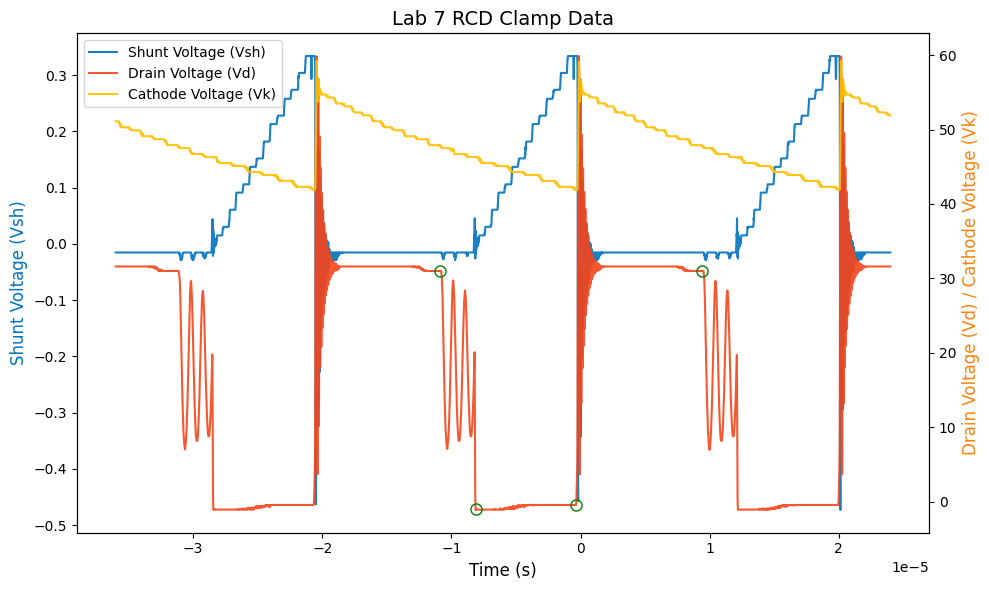

Measured duty cycle (D): 38.20%
Measured switching frequency (Fs): 49285.36Hz


In [95]:
duty = [-1.085e-5, -0.81e-5, -0.035e-5, 0.944e-5] # this is the green circles
slope, ch2_mean, peak_vsh, max_vdrain = plot_rigol(
    "10v_q8_full", 
    "Lab 7 RCD Clamp Data", 
    ch1label="Shunt Voltage (Vsh)", 
    ch2label="Drain Voltage (Vd)", 
    ch3label="Cathode Voltage (Vk)", 
    duty_points=duty, 
    drainx=0.5e-5
)
Ts_measured = duty[3] - duty[0]
D = (duty[2] - duty[1])/Ts_measured
print(f"Measured duty cycle (D): {D:.2%}")
print(f"Measured switching frequency (Fs): {1/Ts_measured:.2f}Hz")

In Lab 7, I calculated the damping ratio to be 0.78 for the high frequency RC snubber.
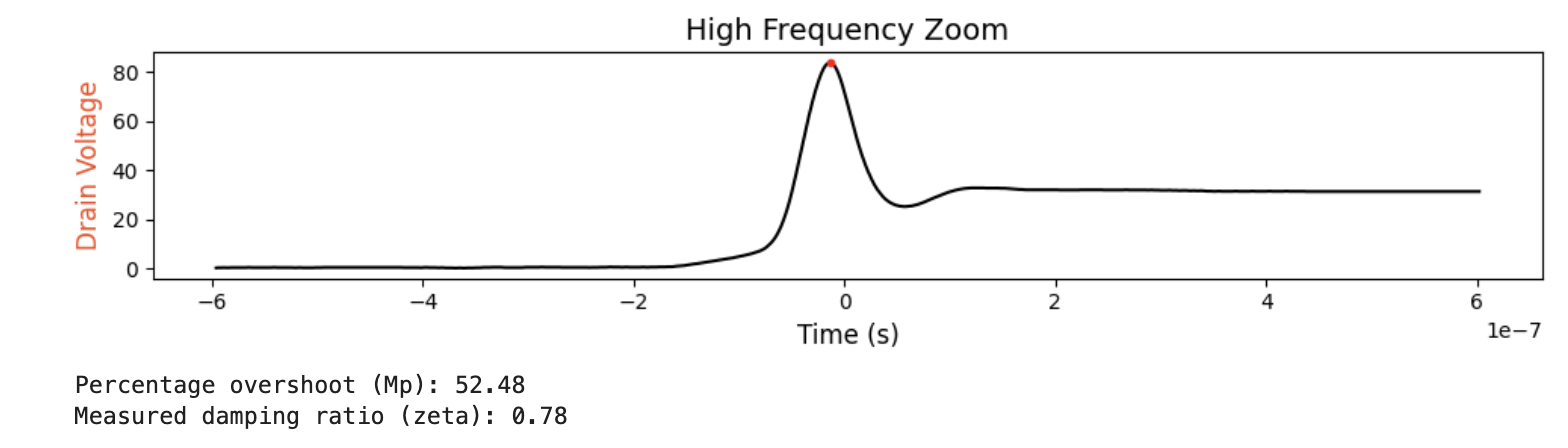

We have proper operation!

### Sources of Loss:
- Conduction losses
    - MOSFET
    - Diode
- Turn-OFF MOSFET Switching Loss
- RCD clamp
- RC Snubber
- Winding Resistance
- Shunt Resistor

Our other sources of loss, such as diode switching, mosfet turn-ON, and off state leakage can be neglected because our flyback converter is operating in DCM with Schottky diode.

### MOSFET Conduction Loss - [FDP61N20](https://www.onsemi.com/pdf/datasheet/fdp61n20-d.pdf):
The equation $I_{rms} = \sqrt{\frac{D}{3}}*I_{pk}$ relates root-mean-squared current to peak current and duty cycle. This helps us determine the appropriate current to calculate the power dissipated by the MOSFET operating in a resistor-like fashion. Since I calculated the duty cycle and peak current in lab 6, we can use those values to first extract an $I_{rms}$ estimate from our collected data.
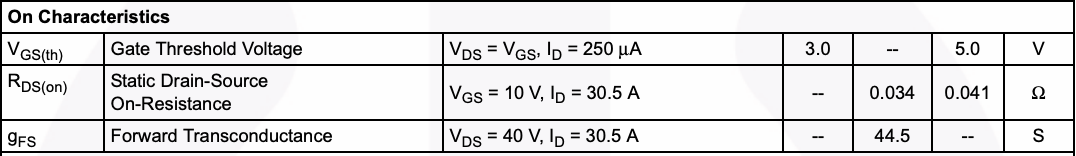
The typical static drain-source on-resistance can be used to then calculate the power dissipated through the MOSFET using the fundamental physics equation $P=I_{rms}^2*R_{ds(on)}$.

In [51]:
import numpy as np
D = 0.3842364532019705 # calculated in lab 6
Ipk = 6.816 # calculated lab 6
Rds_on = 0.034 # typical static drain-source on-resistance
Irms = np.sqrt(D/3)*Ipk
MOSFET_conduction_loss = (Irms**2)*Rds_on
print(f"Time-averaged MOSFET conduction loss: {MOSFET_conduction_loss:.3f}W")

Time-averaged MOSFET conduction loss: 0.202W


### Diode Conduction Loss - [SB350](https://www.vishay.com/docs/88719/sb320.pdf):
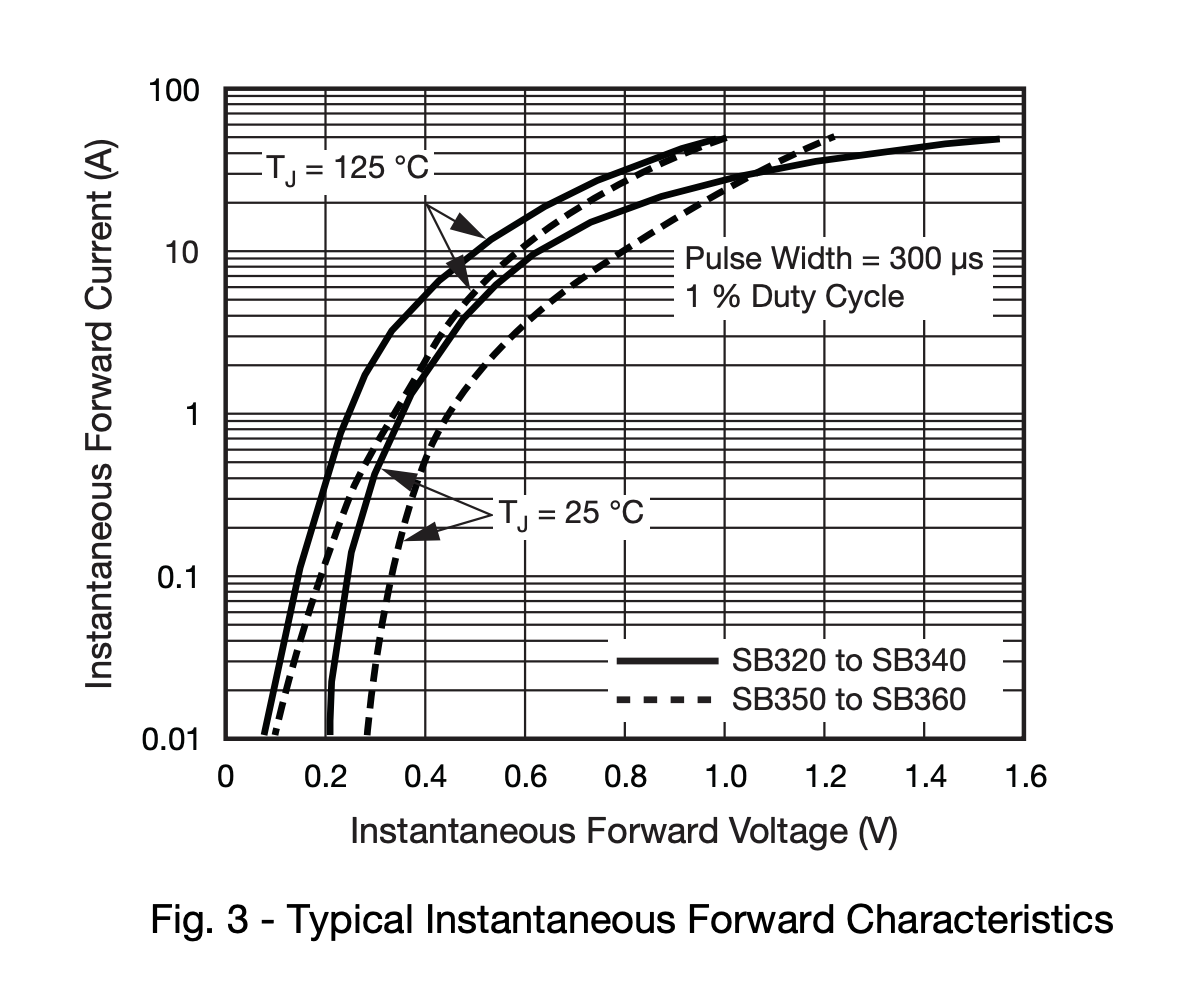

From the 25C curve on the above plot and our knowledge that the output current is 2 amps (given by the output voltage of 10V divided by our known 5$\Omega$ resistor), we can conclude that the instantaneous forward voltage of our Schottky diode is approximately 0.5V on average during conduction. Multiplying the output current by the forward voltage gives us our power loss estimation.

In [52]:
Iout = 2
Vf = 0.5
P_conduction_diode = Iout * Vf
print(f"Diode Conduction Loss: {P_conduction_diode}W")

Diode Conduction Loss: 1.0W


### MOSFET Switching Loss
The typical equation for modeling MOSFET switching loss is $$P_{sw} = \frac{1}{2} \cdot V_{IN} \cdot I_{OUT} \cdot (t_r + t_f) \cdot f_{s}$$ However, this takes into account both the turn off and turn on losses of the MOSFET. However, since we are operating in DCM, there is no current flowing at the moment when the MOSFET switches on, eliminating turn-on losses. Therefore, we modify the equation to $$P_{sw,DCM} = \frac{1}{2} \cdot V_{drain} \cdot I_{pk} \cdot t_f \cdot f_{sw}$$
This relates the peak primary current and only considers the turn off time in our power dissipation analysis. I also substituted in some of the other variable names (for instance, $V_{IN}$ became $V_{drain}$ to match the actual configuration of our flyback converter. We use the maximum $V_{drain}$ in this case because the MOSFET needs to handle that peak during switching loss, and so it would be innaccurate to give it Vg since the leakage inductance/parasitic capacitance ringing would expose the MOSFET to much higher Vds.

In [53]:
max_vd = 56.34
tf = 170e-9 # fall time
Fs = 50000
Psw_loss = 1/2 * max_vd * Ipk * tf * Fs
print(f"MOSFET Switching Loss (turn-off only): {Psw_loss:.2f}W")

MOSFET Switching Loss (turn-off only): 1.63W


### RCD Clamp Loss

In [54]:
avg_clamp_ploss = 0.96 # as calculated in lab 7
print(f"RCD Clamp Loss: {avg_clamp_ploss:.2f}W")

RCD Clamp Loss: 0.96W


### RC Snubber Loss

In [55]:
Irms_plecs = 2.6245e-2
Rsb = 22
P_rc_loss = Irms_plecs*Rsb
print(f"RC Snubber Loss: {P_rc_loss:.2f}W")

RC Snubber Loss: 0.58W


### Winding Resistance
The inner diameter of my bobbin is 8.8 mm and we used 22 AWG wire to wind our 16 turns. The length of each turn can be approximated by adding the inner diameter to the diameter of the wire and multiplying by pi. This multiplied by 9 gives us the total legnth of the wire in mm on the primary side. We then use the resistivity of copper and the Irms current to calculate the power loss through the inductor without considering skin effect.

In [75]:
# the 10 is a rough estimate of how many additional mm it took to get to the pins from the bobbin
primary_length = (np.pi*(8.8 + 0.643)*9 + 10)*1e-3 
secondary_length = (np.pi*(8.8 + 0.643)*7 + 10)*1e-3 
cu_p = 1.724e-8
wire_area = 0.326 * 1e-6
Rwp = cu_p * primary_length / wire_area
Rws = cu_p * secondary_length / wire_area
Irms_secondary = Irms * (9/7)
Rw_loss = Irms ** 2 * Rwp + Irms_secondary ** 2 * Rws

print(f"Rw loss: {Rw_loss:.2f}W")

Rw loss: 0.20W


### Secondary Shunt Resistor

In [57]:
P_sec_shunt = Iout**2 * 0.05
print(f"Power lost through output shunt: {P_sec_shunt}W")

Power lost through output shunt: 0.2W


### [Core](https://www.ferroxcube.com/upload/media/product/file/Pr_ds/PQ20_20.pdf) Loss
From the datasheet, we know that our minimum area is 59.1 mm^2. Also, we can see in the PC95 material datasheet the relation between the flux density and core loss:
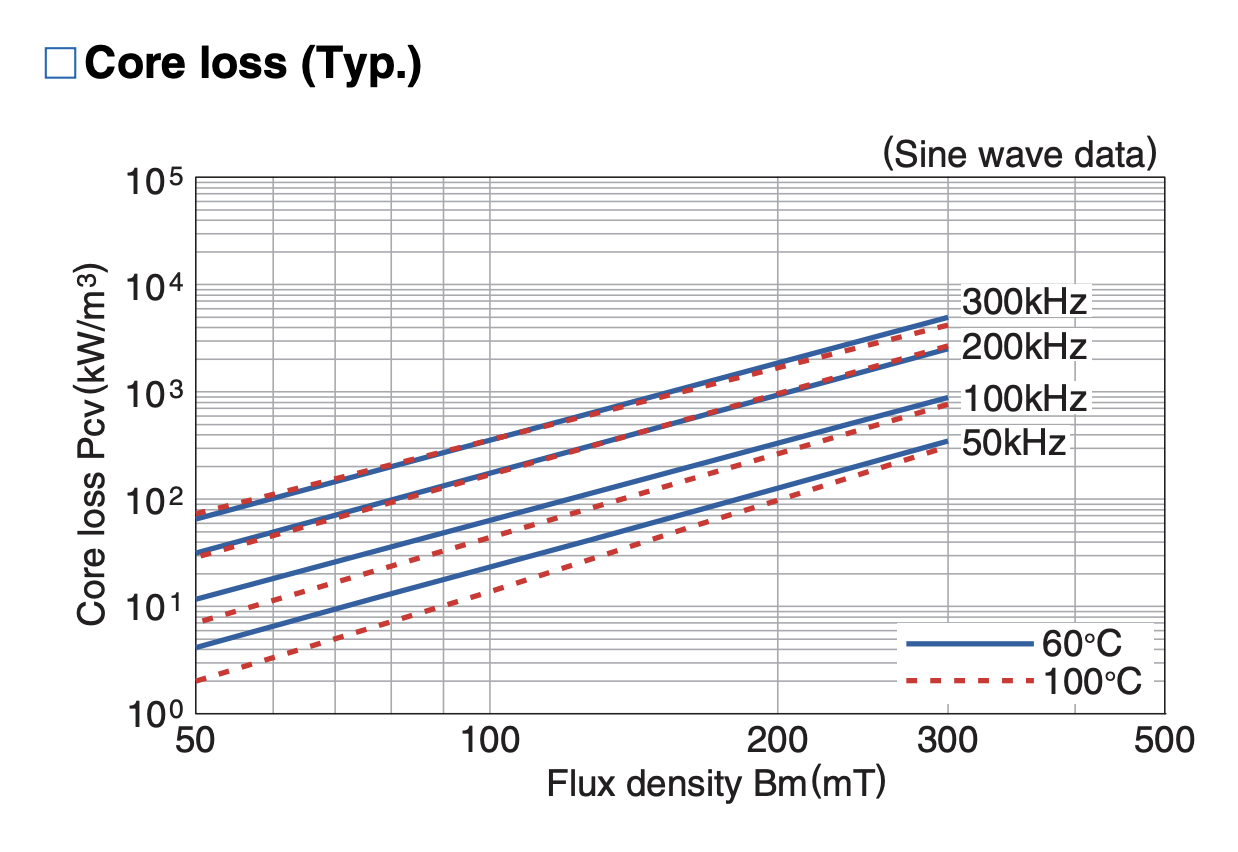

In [58]:
Amin = 5.91e-5 # m^2
L_measured = 1.9805578e-05 # from lab 6
phi = (L_measured * Irms) / 9 # 9 primary turns
B = phi/Amin
print(f"RMS flux density: {B*1e3:.2f}mT")

RMS flux density: 90.83mT


Reading the chart above tells us that the core loss is ~20 kw/m^3

In [59]:
Pcv = 20
Ve = 2.85e-6 # in m^3
P_core_loss = 1000*(Pcv * Ve)
print(f"Core loss: {P_core_loss:.3f}W") 

Core loss: 0.057W


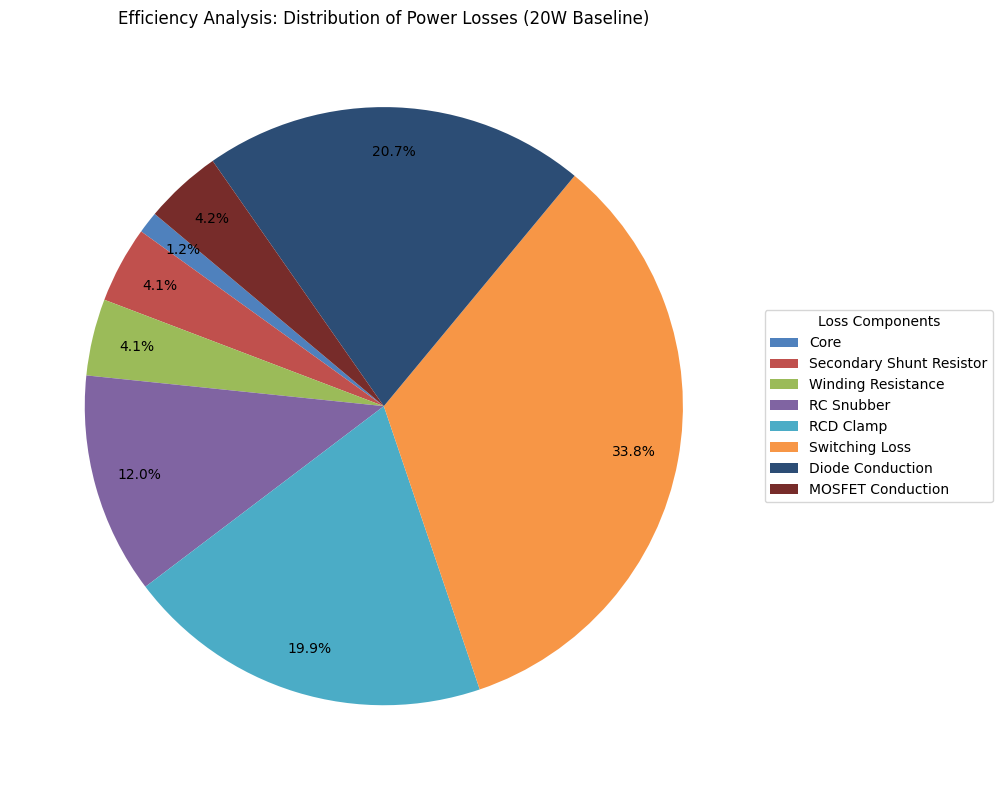

4.83W total lost (prelab)


In [83]:
labels = [
    "Core", "Secondary Shunt Resistor", "Winding Resistance", 
    "RC Snubber", "RCD Clamp", "Switching Loss", 
    "Diode Conduction", "MOSFET Conduction"
]
prelab_losses = [
    P_core_loss, P_sec_shunt, Rw_loss, P_rc_loss, 
    avg_clamp_ploss, Psw_loss, P_conduction_diode, MOSFET_conduction_loss
]
colors = ['#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6', '#F79646', '#2C4D75', '#772C2A']

plt.figure(figsize=(12, 8))
plt.pie(prelab_losses, labels=None, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.85)

plt.legend(labels, title="Loss Components", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Efficiency Analysis: Distribution of Power Losses (20W Baseline)")
plt.tight_layout()
plt.show()

print(f"{np.sum(prelab_losses):.2f}W total lost (prelab)")

### Q1: Confirm that the converter is operating in discontinuous conduction mode at a duty cycle of approximately 35%.

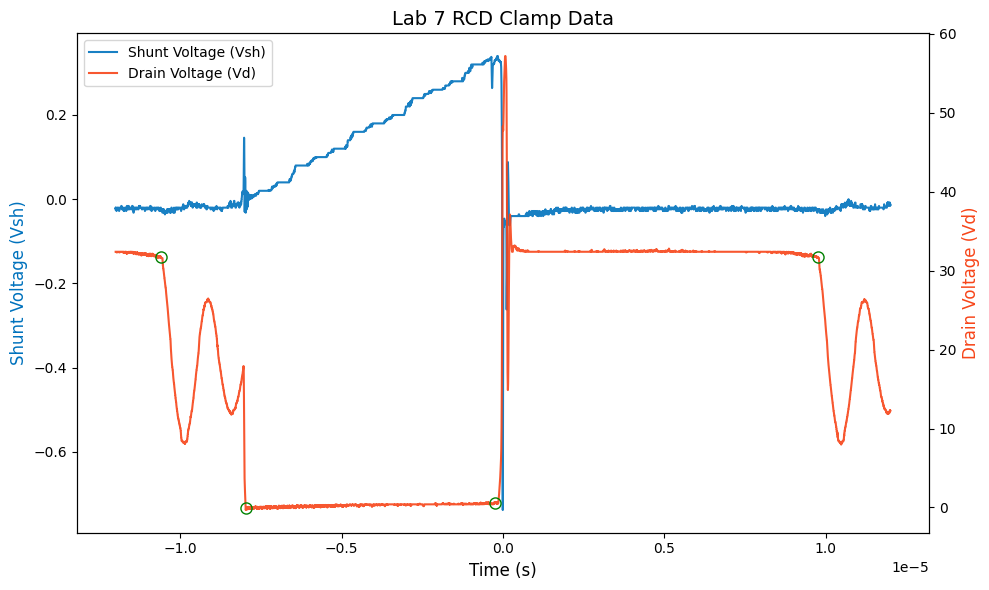

Measured duty cycle (D): 37.79%
Measured switching frequency (Fs): 49140.05Hz


In [61]:
duty = [-1.06e-5, -0.795e-5, -0.026e-5, 0.975e-5] # this is the green circles
slope, ch2_mean, peak_vsh, max_vdrain = plot_rigol(
    "baseline_q1", 
    "Lab 7 RCD Clamp Data", 
    ch1label="Shunt Voltage (Vsh)", 
    ch2label="Drain Voltage (Vd)", 
    ch3label="Cathode Voltage (Vk)", 
    duty_points=duty, 
    drainx=0.5e-5
)
Ts_measured = duty[3] - duty[0]
D = (duty[2] - duty[1])/Ts_measured
print(f"Measured duty cycle (D): {D:.2%}")
print(f"Measured switching frequency (Fs): {1/Ts_measured:.2f}Hz")

### Q2: Determine the efficiency of the converter as well as the total power lost.
Baseline input voltage: 18V

Baseline input current: 1.41A

Output Voltage: 10V

Load Resistance: 5$\Omega$

In [62]:
P_out = 10/5*10
P_in = 18*1.41
print(f"Our efficiency is {P_out/P_in:.2%}")
print(f"Total power lost: {P_in - P_out:.2f}W")

Our efficiency is 78.80%
Total power lost: 5.38W


### Q3/Q4: Determine efficiency and the amount of power dissipated at each 1V decrement until boundary conduction is reached.

In [88]:
# Efficiency Calculations:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_eff = pd.read_csv('data/efficiency.csv', sep='\t')

pin_vector = df_eff.iloc[:, 4].values
pout_vector = df_eff.iloc[:, 5].values

efficiency_vector = (pout_vector / pin_vector) * 100
ploss_vector = pin_vector - pout_vector
df_eff['Efficiency (%)'] = efficiency_vector
df_eff['Power Loss (W)'] = ploss_vector
display(df_eff)

,Vin,Iin,Vout,Iout,Pin,Pout,Efficiency (%),Power Loss (W)
0,18.00,1.13,9,1.80,20.34,16.20,79.65,4.14
1,17.00,1.20,9,1.80,20.40,16.20,79.41,4.20
2,16.00,1.27,9,1.80,20.32,16.20,79.72,4.12
3,15.00,1.35,9,1.80,20.25,16.20,80.00,4.05
4,14.00,1.46,9,1.80,20.44,16.20,79.26,4.24
5,13.50,1.52,9,1.80,20.52,16.20,78.95,4.32


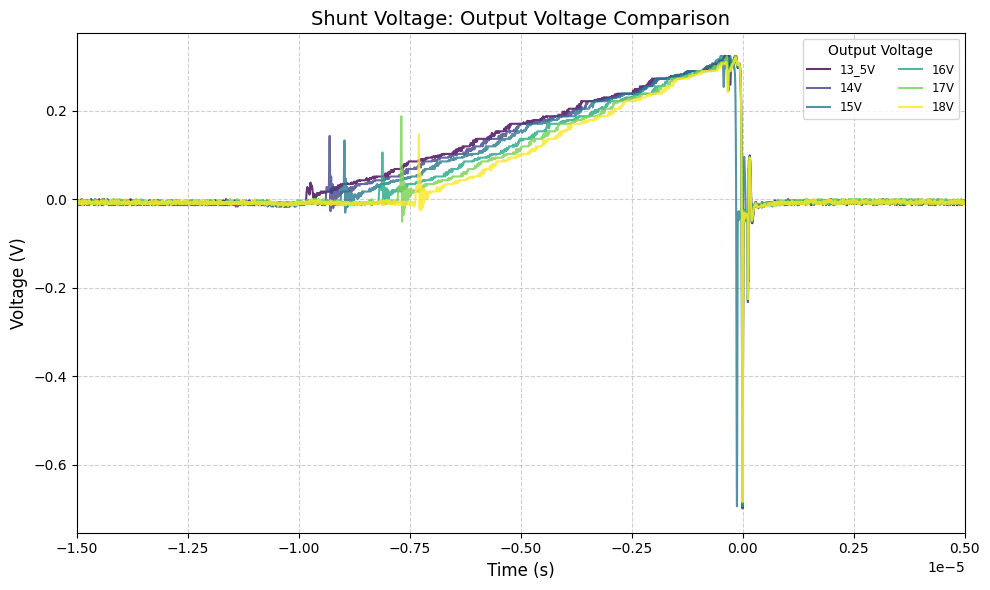

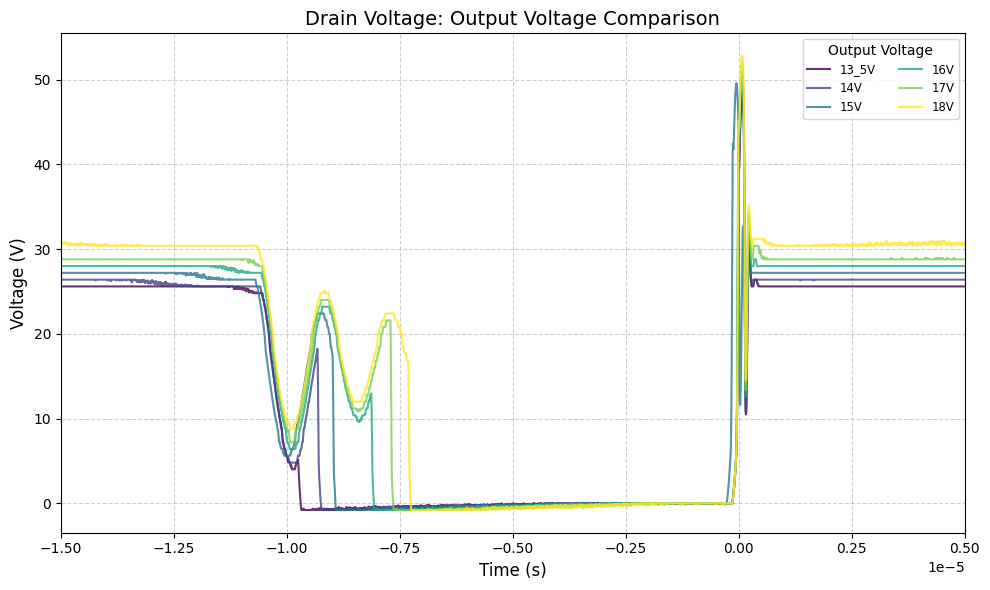

In [64]:
import numpy as np

def plot_multiple_rigol_files(file_list, x_limits=None, custom_labels=None):
    """
    Reads multiple Rigol CSVs and overlays them on two separate plots.
    
    Args:
        file_list: List of filenames (e.g., ["test1", "test2"]) without .csv extension.
        custom_labels: List of labels for the legend. Defaults to filenames.
    """
    fig_sh, ax_sh = plt.subplots(figsize=(10, 6))
    fig_vd, ax_vd = plt.subplots(figsize=(10, 6))

    colors = plt.cm.viridis(np.linspace(0, 1, len(file_list)))

    for i, filename in enumerate(file_list):
        filepath = f"data/{filename}.csv"
        try:
            data, t0, dT = read_rigol_csv(filepath)
        except FileNotFoundError:
            print(f"Warning: {filepath} not found. Skipping.")
            continue

        v_shunt = get_channel_data(data, 'CH1')
        v_drain = get_channel_data(data, 'CH2')
        label = custom_labels[i] if custom_labels else (filename + "V")
        if v_shunt is not None:
            ax_sh.plot(data['X'], v_shunt, label=label, color=colors[i], alpha=0.8)
        if v_drain is not None:
            ax_vd.plot(data['X'], v_drain, label=label, color=colors[i], alpha=0.8)

    for ax in [ax_sh, ax_vd]:
        if x_limits:
            ax.set_xlim(x_limits)
        ax.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
        ax.grid(True, linestyle='--', alpha=0.5)

    ax_sh.set_title("Shunt Voltage: Output Voltage Comparison", fontsize=TITLE_FONTSIZE)
    ax_sh.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax_sh.set_ylabel("Voltage (V)", fontsize=AXES_FONTSIZE)
    ax_sh.legend(loc='best', fontsize='small', ncol=2, title="Output Voltage")
    ax_sh.grid(True, linestyle='--', alpha=0.6)
    fig_sh.tight_layout()

    ax_vd.set_title("Drain Voltage: Output Voltage Comparison", fontsize=TITLE_FONTSIZE)
    ax_vd.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax_vd.set_ylabel("Voltage (V)", fontsize=AXES_FONTSIZE)
    ax_vd.legend(loc='best', fontsize='small', ncol=2, title="Output Voltage")
    ax_vd.grid(True, linestyle='--', alpha=0.6)
    fig_vd.tight_layout()

    plt.show()

filenames = ["13_5", "14", "15", "16", "17", "18"]
plot_multiple_rigol_files(filenames, [-1.5e-5, 0.5e-5])

### Q5/Q8: Use the IR camera to identify heat producing components on the board.
Top View:

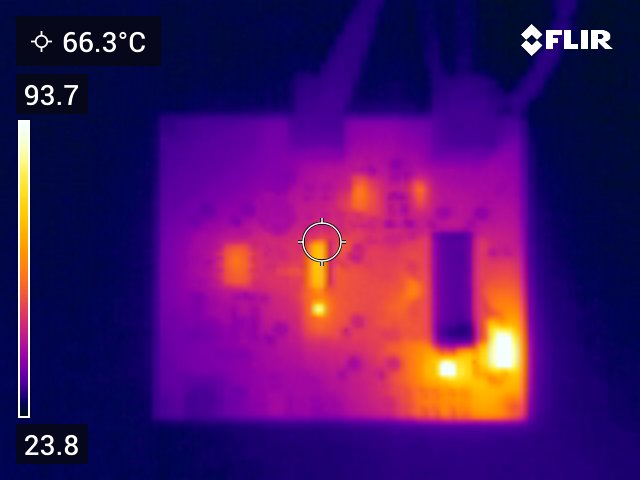

Left View:

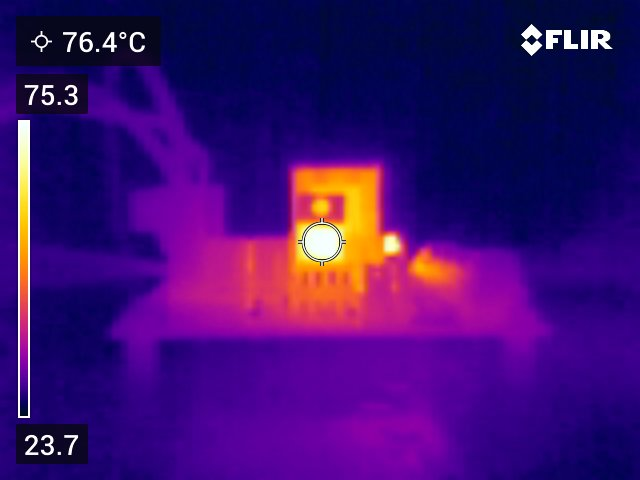

Right View:

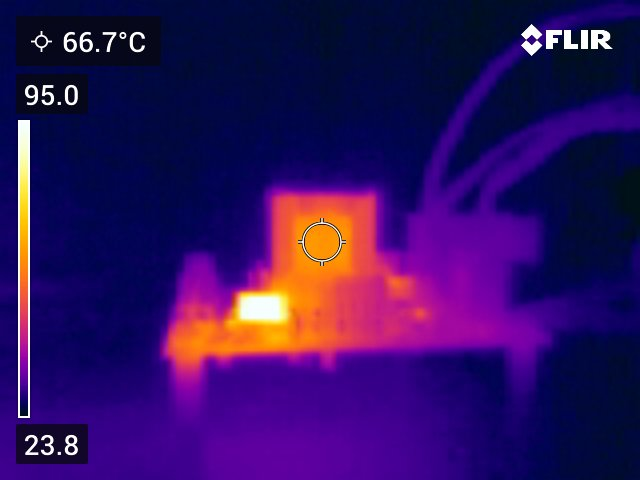

Top View - Lower Right Zoom:

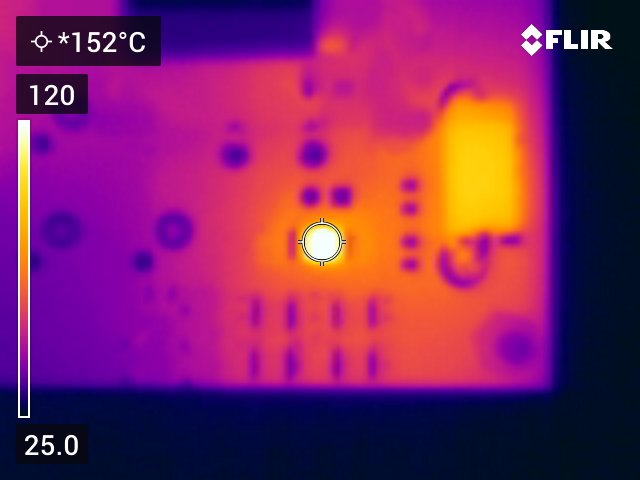

The hottest components on the board include the MOSFET, the shunt resistors, the ferrite core of the transformer, the diodes, and the UC2488 itself. Of these, the hottest component by far was the secondary current shunt resistor. The clamp resistor was also somewhat warmer than the rest of the board, but relative to other components was not particularly hot.

### Q7: Consider the overall efficiency and sum of all losses measured
I did not consider primary shunt resistor loss or chip loss in my initial sum of all losses measured. The average supply current according to recommended operating conditions is 25mA.

In [77]:
# Primary shunt resistor loss
Rsh = 0.05
P_primary_shunt = Irms ** 2 * Rsh
print(f"Primary shunt resistance loss: {P_primary_shunt:.2f}W")

Primary shunt resistance loss: 0.30W


In [69]:
# UC2844 loss: Vcc * Iout
Vcc = 18 # the chip is powered by Vg
I_vcc = 25e-3
P_chip = Vcc * I_vcc
print(f"Power loss through chip: {P_chip:.2f}W")

Power loss through chip: 0.45W


### Q10: Create an updated pie chart.

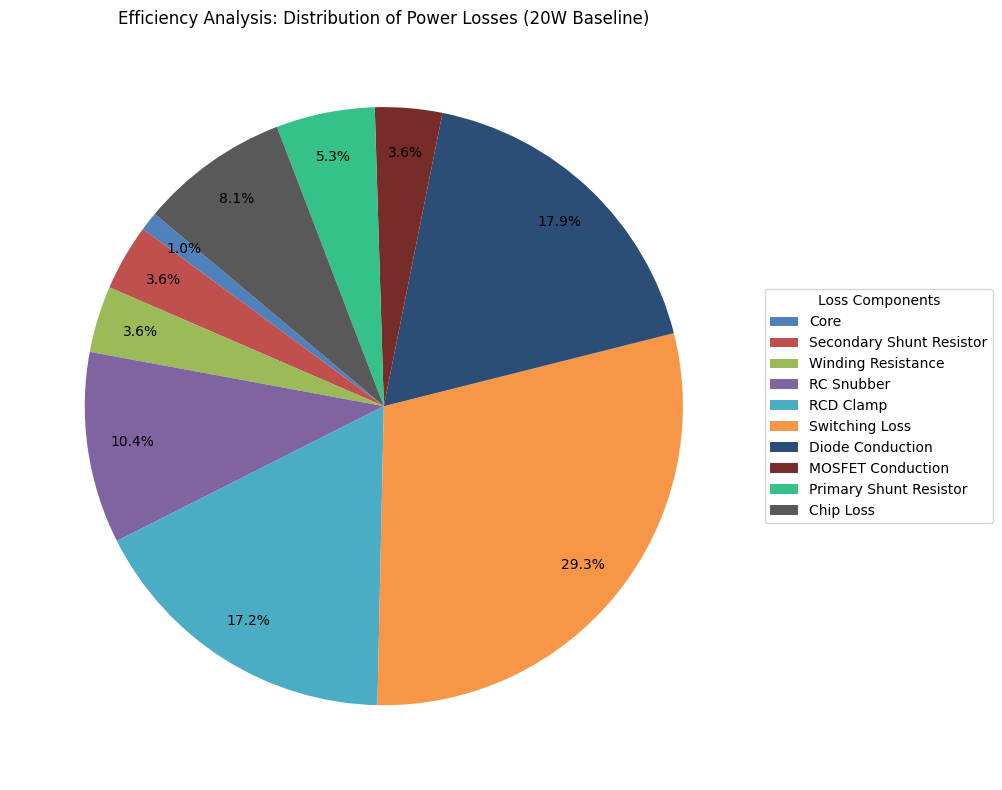

5.58W lost total


In [84]:
labels = [
    "Core", "Secondary Shunt Resistor", "Winding Resistance", 
    "RC Snubber", "RCD Clamp", "Switching Loss", 
    "Diode Conduction", "MOSFET Conduction", 
    "Primary Shunt Resistor", "Chip Loss"
]

losses = [
    P_core_loss, P_sec_shunt, Rw_loss, P_rc_loss, 
    avg_clamp_ploss, Psw_loss, P_conduction_diode, 
    MOSFET_conduction_loss, P_primary_shunt, P_chip
]

colors = [
    '#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6', 
    '#F79646', '#2C4D75', '#772C2A', '#34C289', '#595959'
]
plt.figure(figsize=(12, 8))
plt.pie(losses, labels=None, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.85)

plt.legend(labels, title="Loss Components", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Efficiency Analysis: Distribution of Power Losses (20W Baseline)")
plt.tight_layout()
plt.show()
print(f"{np.sum(losses):.2f}W lost total")

It's interesting how much of this is occupied by switching loss when the MOSFET does not seem to be the hottest thing on the board. It's possible that because of the metal back it's better at sinking heat into the air than something like the 1206 shunt resistor. Also, my new calculated overall loss is now even greater than the actual loss, so I must me overestimating the loss in some of these components.

### Q11: What is the trend in terms of total loss?

There doesn't seem to be a clear trend in terms of total loss. 15V seems to be an especially large outlier, with 80% efficiency and only 4.05W lost. This is less loss than the values that I estimated. I would have expected that the loss would go up as the input voltage decreased because of the multiple components with loss dependent on $I_{rms}$, but there isn't a particularly clear trend in my data. Switching loss follows the opposite trend as I will soon discuss.

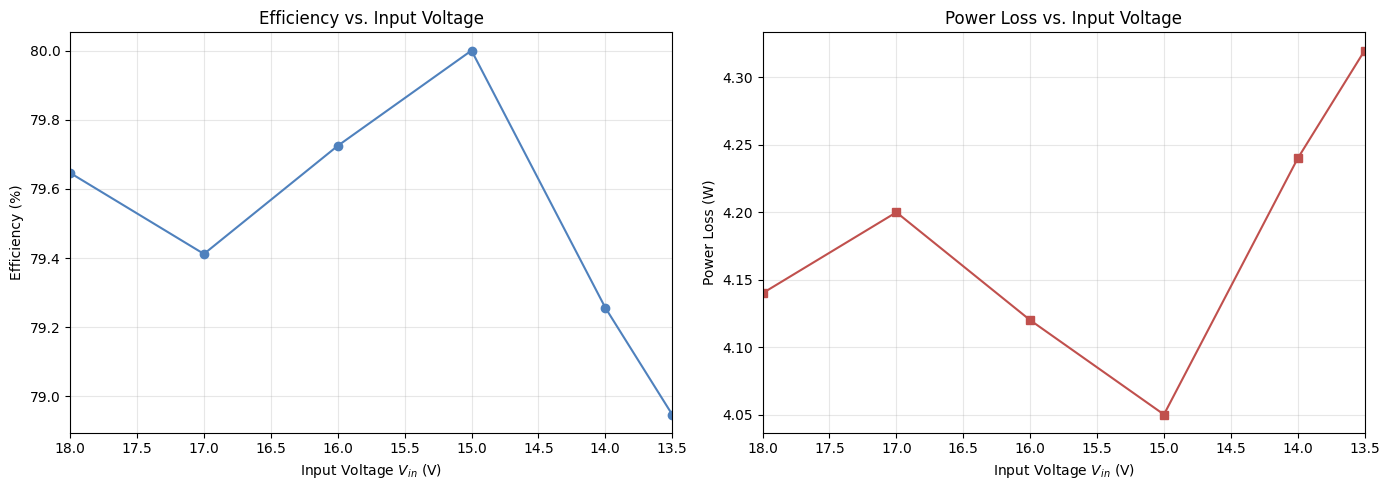

,Vin,Iin,Vout,Iout,Pin,Pout,Efficiency (%),Power Loss (W)
0,18.00,1.13,9,1.80,20.34,16.20,79.65,4.14
1,17.00,1.20,9,1.80,20.40,16.20,79.41,4.20
2,16.00,1.27,9,1.80,20.32,16.20,79.72,4.12
3,15.00,1.35,9,1.80,20.25,16.20,80.00,4.05
4,14.00,1.46,9,1.80,20.44,16.20,79.26,4.24
5,13.50,1.52,9,1.80,20.52,16.20,78.95,4.32


In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_eff['Vin'], df_eff['Efficiency (%)'], marker='o', linestyle='-', color='#4F81BD', label='Efficiency')
ax1.set_xlabel('Input Voltage $V_{in}$ (V)')
ax1.set_ylabel('Efficiency (%)')
ax1.set_title('Efficiency vs. Input Voltage')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(18, 13.5)

ax2.plot(df_eff['Vin'], df_eff['Power Loss (W)'], marker='s', linestyle='-', color='#C0504D', label='Total Loss')
ax2.set_xlabel('Input Voltage $V_{in}$ (V)')
ax2.set_ylabel('Power Loss (W)')
ax2.set_title('Power Loss vs. Input Voltage')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(18, 13.5)

plt.tight_layout()
plt.show()
display(df_eff)

### Q12: How would you expect the individual losses to change as the input voltage is reduced?
Irms would increase as the input voltage went down since we are requesting the same power output at the output, hence why I_in increases as Vg drops. Switching loss, as calculated earlier, is determined using Psw = 1/2 * Vdrain * Ipk * tf * Fs, for which the switching frequency is decreasing and the drain voltage is also decreasing (observable on the Vdrain overlay plot). These two factors decreasing would decrease the power lost from switching, while the increase in current would cause the other components to dissipate more power as Vg decreases. Thus, as input voltage decreases, I would expect switching loss to occupy a smaller proportion of the overall loss.

### Q13: Does this give us any further information about the distribution of losses?
If a decrease in Vg corresponded to a decrease in total loss like I hypothesized, it would imply that the overall loss is less concentrated in the RMS current affected components/sources of loss, which include but are not limited to the winding resistance, the chip loss since VCC is connected to Vg, the diode and MOSFET conduction loss, and the shunt resistances. In terms of the distribution trend, I_rms losses and switching losses are inversely related -- I_rms losses should increase as the input voltage goes down, while switching losses should decrease. However, my collected data doesn't conclusively explain the relationship between loss and input voltage.

### Q14: Brainstorm idea for how the converter efficiency could be improved when operating at 18 V input, 10 V output
I could choose a MOSFET with a lower Rds(on) for lower conduction losses, I could use a diode with a lower forward voltage, or I could even use a lower power chip. I could also use an even lower shunt resistance value and reduce winding resistance using a different type of wire (whether that be a different gauge or possibly Litz wire since there are likely skin effects that are not calculated here) or winding pattern.

### Independent Steps

1. I read [this article](https://www.allaboutcircuits.com/technical-articles/introduction-to-mosfet-switching-losses/) about MOSFET switching losses. It helped me figure out how to do some of the loss calculations initially, but covers similar content to my lab above (e.g. how to calculate switching loss was taken from this)
2. I read [this short article](https://www.shindengen.com/products/semi/column/basic/mosfet/mosfet_on_resistance.html) about MOSFET RDS(ON) decreasing strategies and what the actual differences are between MOSFETs with large and small Rds(on)s. I learned that Rds(on) is affected by having a depletion region that can expand easily, chemical composition (GaN vs SiC) and the bare die size. However, increasing the die size will increase capacitance, which contributes to switching loss. 